# Exercise 7: Deeper dive into `geopandas`

Skills:

* Attributes to get from `geometry`
* Buffering
* Multiple `geometry` columns
* Clipping
* Spatial joins - more discussion on `how` and `predicate` arguments
* Overlay - more discussion on `how` arguments

References:
* spatial join vs overlay [explanation](https://groups.google.com/g/geopandas/c/H_qzH2T5cCE)
* `geopandas` tutorials by package creator: https://github.com/jorisvandenbossche/geopandas-tutorial
* `geopandas` concepts, explanations, but datasets use Hebrew: https://geobgu.xyz/py/geopandas2.html
* Advanced spatial modeling concepts: https://geographicdata.science/book/notebooks/01_geo_thinking.html
* [PyGIS](https://pygis.io/docs/a_intro.html) Geospatial Tutorials (focus on ch 1-3)
* 7 crucial geoprocessing [tools](https://gisgeography.com/geoprocessing-tools/)

In [1]:
import geopandas as gpd
import intake
import pandas as pd

catalog = intake.open_catalog("shared_data_catalog.yml") # NOTE: since this is no longer in calitp/data-analyses, this file needs to be added to the repo

In [2]:
districts = catalog.caltrans_districts.read()
stops = catalog.ca_transit_stops.read()

## Attributes to get from `geometry`

A lot of information is stored in the `geometry` column. 
Take a look at each of the attributes for each of the datasets.

For each gdf, look at:
* its coordinate reference system (`gdf.crs`) 
* which column is its geometry (`gdf.geometry.name`)
* for a point, get the x, y of the first row (`gdf.geometry.x`, `gdf.geometry.y`)
* for a line, get the length of the first row (`gdf.geometry.length`)
* for a polygon, get the area of the first row (`gdf.geometry.area`)
* note: the length and area must be in units that can be interpreted, such as meters, feet, miles, etc and not decimal degrees.

In [3]:
districts.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
districts.geometry.name

'geometry'

In [5]:
stops.geometry.iloc[0].x, stops.geometry.iloc[0].y

(-118.371902, 33.837469)

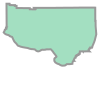

In [6]:
districts[districts.DISTRICT==7].geometry.iloc[0]

In [7]:
districts = districts.to_crs("EPSG:2229") #unit in feet
one_geom = districts[districts.DISTRICT==7].geometry.iloc[0]
print(type(one_geom))

<class 'shapely.geometry.polygon.Polygon'>


In [8]:
one_geom.area

172532595239.97144

## Buffering

Typically, you want to draw some radius around a geometry. This is buffering. It is most often used for points and lines, but occasionally, you'll use it for polygons too. The result of a buffer is always a polygon. 

Examples of questions you're asking:
* how many destinations can I reach within 5 miles from my location? (my location is a point, and a 5 mile buffer should be drawn)
* how many bus stops are on this road? Well, it's highly unlikely you'll have a bus stop (point) fall exactly on the road (line) in your dataset. Instead, you can draw a small buffer (maybe 20 meters) around the road and see how many bus stops fall within it.

Draw a buffer of 50 meters around the stop and set the `geometry` column to be the buffered geometry.

gdfs can hold multiple geometry columns, and geoparquets and GeoJSONs can save files with multiple geometry columns.

In [9]:
stops = stops.to_crs("EPSG:3310") # unit in meters
stops = stops.assign(
    geometry_buffered = stops.geometry.buffer(50)
)

stops[["agency", "stop_id", "stop_name", 
       "geometry", "geometry_buffered"]].head(2)

,agency,stop_id,stop_name,geometry,geometry_buffered
0,City of Gardena,394,Bishop Montgomery High School,POINT (150713.641 -462899.560),"POLYGON ((150763.641 -462899.560, 150763.400 -..."
1,City of Gardena,395,Redondo Beach & Hawthorne Blvd,POINT (152490.159 -458756.913),"POLYGON ((152540.159 -458756.913, 152539.918 -..."


## Multiple `geometry` columns

By default, the `geometry` column is used. But, if you have another `geometry` column you'd like to use, you can set it.

In [10]:
stops2 = stops[stops.agency.str.contains("City of Santa Monica") # NOTE: Needs to be changed from "Big Big" to something containing "Santa Monica"
].set_geometry("geometry_buffered")

print(f"stops geometry: {stops.geometry.name}")
print(f"stops2 geometry: {stops2.geometry.name}")

stops geometry: geometry
stops2 geometry: geometry_buffered


In [11]:
stops.agency.loc[stops.agency.str.contains("Monica")]

106264    City of Santa Monica
106265    City of Santa Monica
106266    City of Santa Monica
106267    City of Santa Monica
106268    City of Santa Monica
                  ...         
107191    City of Santa Monica
107192    City of Santa Monica
107193    City of Santa Monica
107194    City of Santa Monica
107195    City of Santa Monica
Name: agency, Length: 932, dtype: object

In [12]:
stops2.head(10).explore(tiles="CartoDB Positron")

In [13]:
# you can reset the geometry column on-the-fly just for mapping
stops2.head(10).set_geometry("geometry").explore(
    tiles='CartoDB Positron')

## Dissolve

Dissolve is a way to aggregate in the geospatial world. It's a way to combine multiple rows, and their geometries, into 1 row. You can also calculate statistics in the dissolve, such as `count`, `sum`, etc. 

<AxesSubplot:>

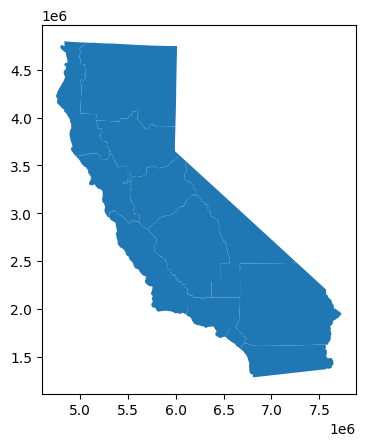

In [14]:
# There are 12 Caltrans districts
# Use dissolve to combine the 12 district polygons into 
# 1 large CA polygon 
districts.plot()

<AxesSubplot:>

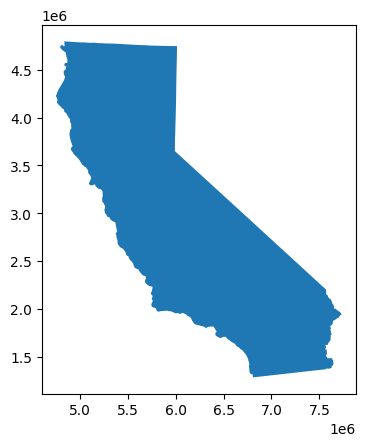

In [15]:
ca = districts.dissolve()
ca.plot()

In [16]:
ca

,geometry,OBJECTID,DISTRICT,Region,Shape__Area,Shape__Length
0,"POLYGON ((6105565.229 1946214.162, 6102975.223...",1,1,North,4.659910e+10,1.644579e+06


Look at the gdf returned. Why does it say `DISTRICT==1`, yet the entire CA boundary is shown?

[Docs explanation](https://geopandas.org/en/stable/docs/user_guide/aggregation_with_dissolve.html). By default, the first value is kept.

Instead, let's count how many districts there are and sum up the area.

In [17]:
districts2 = districts.assign(
    state = "CA"
) 
districts2.head(2)

,OBJECTID,DISTRICT,Region,Shape__Area,Shape__Length,geometry,state
0,1,1,North,4.659910e+10,1.644579e+06,"POLYGON ((5050292.349 4784444.908, 5050260.600...",CA
1,2,2,North,1.266950e+11,1.775639e+06,"POLYGON ((5382628.905 4770985.627, 5371797.907...",CA


In [18]:
districts2[["state", "Shape__Area", "geometry"]].head(2)

,state,Shape__Area,geometry
0,CA,4.659910e+10,"POLYGON ((5050292.349 4784444.908, 5050260.600..."
1,CA,1.266950e+11,"POLYGON ((5382628.905 4770985.627, 5371797.907..."


In [19]:
ca2 = (districts2[["state", "DISTRICT", "Shape__Area", "geometry"]]
 .dissolve(
    by=["state"], 
     aggfunc={
        "DISTRICT": "count",
        "Shape__Area": "sum"})
 .reset_index()
)

ca2

,state,geometry,DISTRICT,Shape__Area
0,CA,"POLYGON ((6105565.229 1946214.162, 6102975.223...",12,6.654531e+11


<AxesSubplot:>

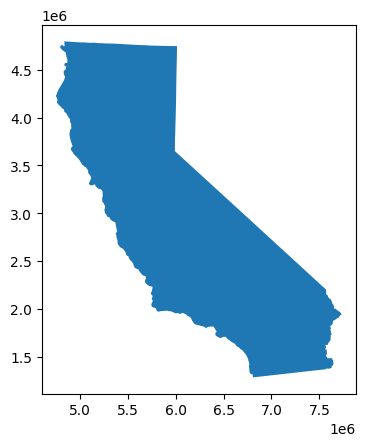

In [20]:
ca2.plot()

## Clipping

Clipping is a technique to narrow down one gdf by the boundaries of another gdf. The other gdf is called the mask. 

[Docs](https://geopandas.org/en/stable/gallery/plot_clip.html) here and [here](https://geopandas.org/en/stable/docs/reference/api/geopandas.clip.html).

Examples:
* which transit stops fall within District 7?
* find Amtrak routes within CA (cut away the lines that fall outside of CA, but keep the lines that fall within CA)

| current gdf | current geometry type | mask gdf    | 
|-------------|-----------------------|-------------|
| stops       | point                 | district    | 
| routes      | line                  | state       |


In [21]:
stops.head()

,org_id,agency,stop_id,stop_name,n_routes,route_ids_served,routetypes,n_arrivals,n_hours_in_service,meters_to_ca_state_highway,base64_url,district_name,geometry,geometry_buffered
0,recX4nQfupRQf3xGD,City of Gardena,394,Bishop Montgomery High School,1,3SCH,3,1,1,1244.5,aHR0cHM6Ly9yaWRlZ3RyYW5zLmNvbS9ndGZzLnppcA==,07 - Los Angeles / Ventura,POINT (150713.641 -462899.560),"POLYGON ((150763.641 -462899.560, 150763.400 -..."
1,recX4nQfupRQf3xGD,City of Gardena,395,Redondo Beach & Hawthorne Blvd,1,3SCH,3,1,1,40.9,aHR0cHM6Ly9yaWRlZ3RyYW5zLmNvbS9ndGZzLnppcA==,07 - Los Angeles / Ventura,POINT (152490.159 -458756.913),"POLYGON ((152540.159 -458756.913, 152539.918 -..."
2,recX4nQfupRQf3xGD,City of Gardena,396,163rd st & Vermont,1,3SCH,3,1,1,589.7,aHR0cHM6Ly9yaWRlZ3RyYW5zLmNvbS9ndGZzLnppcA==,07 - Los Angeles / Ventura,POINT (158040.823 -457662.882),"POLYGON ((158090.823 -457662.882, 158090.582 -..."
3,recX4nQfupRQf3xGD,City of Gardena,482,Hawthorne & Artesia Blvd,1,3SCH,3,1,1,9.4,aHR0cHM6Ly9yaWRlZ3RyYW5zLmNvbS9ndGZzLnppcA==,07 - Los Angeles / Ventura,POINT (152414.723 -459001.257),"POLYGON ((152464.723 -459001.257, 152464.482 -..."
4,recX4nQfupRQf3xGD,City of Gardena,409,Arrive Bishop Montgomery,1,3SCH,3,1,1,1244.5,aHR0cHM6Ly9yaWRlZ3RyYW5zLmNvbS9ndGZzLnppcA==,07 - Los Angeles / Ventura,POINT (150713.639 -462899.449),"POLYGON ((150763.639 -462899.449, 150763.398 -..."


In [56]:
stops_route_type_processing = stops.copy()
# Get routetypes as an iterable so it can be exploded
stops_route_type_processing["routetypes_iterable"] = stops_route_type_processing["routetypes"].str.split(", ")
# Exploded the stops df on routetypes
stops_exploded_by_route_type = stops_route_type_processing.explode(
    "routetypes_iterable"
).rename(
    columns={"routetypes_iterable": "route_type"}
).reset_index(names="original_index") # Keep the original index so we can identify duplicate stops later
amtrak_stops = stops_exploded_by_route_type.loc[
    (
        (stops_exploded_by_route_type.route_type.isin(['0', '1', '2'])) &  # Filter route types to remove Thruway buses
        (stops_exploded_by_route_type.agency=="Amtrak") # Filter for only Amtrak routes
    ),
    ["original_index", "agency", "stop_id", "stop_name", "geometry"]
].drop_duplicates( # Drop any duplicate stops after we filter by route type, in case they had multiple of the listed route 
    subset="original_index"
).reset_index(
    drop=True
).drop( # Drop original_index, since we don't need it anymore
    "original_index", axis=1
)


In [57]:
stops_exploded_by_route_type.route_type.value_counts()

3    128548
2      1860
0      1764
5       232
1        66
4        50
Name: route_type, dtype: int64

In [58]:
amtrak_stops.to_crs("EPSG:4326").clip(
    ca.to_crs("EPSG:4326")
).explore() #NOTE I changed this from .plot to .explore, since .plot isn't very easy to look at. Also not sure why San Joaquins and Zephyr stops are dropped?

## Spatial Join

You are asking questions about your current gdf, but require information from another gdf. A spatial join allows you to attach columns from another gdf to the current gdf.

Spatial joins do not change the **values** in the `geometry` column. The `how=` and `predicate=` arguments determine **which rows** are kept and **which geometry** column is kept. It does not change the contents of the geometry the way `gpd.overlay()` does.

* Which county does this stop belong in?
* Which bus routes run in District 7?
* Which state does this district belong in? 

| current gdf | current geometry type | another gdf | concept            |
|-------------|-----------------------|-------------|--------------------|
| stops       | point                 | county      | point-in-polygon   |
| highways    | line                  | district    | line-in-polygon    |
| districts   | polygon               | state       | polygon-in-polygon |

In [59]:
# There are 789 stops!
amtrak_stops.shape

(1056, 4)

<AxesSubplot:>

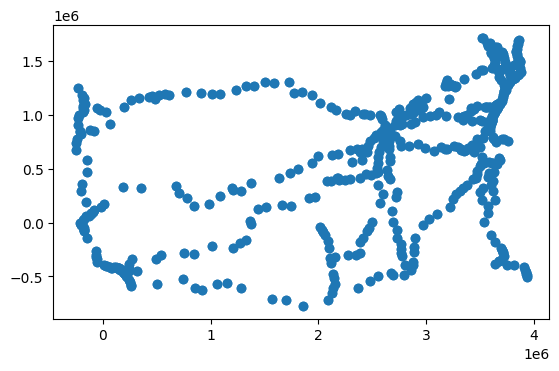

In [60]:
amtrak_stops.plot()

It looks like Amtrak stops across the US are shown.

To find which ones are located in CA, we are asking a point-in-polygon question. Which Amtrak stop (point) falls in CA (polygon)?

A spatial join can tell us this.

### Explore the various `how=` and `predicate=` arguments
* Read [docs](https://geopandas.org/en/stable/docs/user_guide/set_operations.html)
* [predicate and how explanation](https://geopandas.org/en/stable/docs/user_guide/mergingdata.html)


#### predicate = intersects / within 
* `predicate` specifies which spatial set operation you're using. Is it a point **within** a polygon? Is it a **point** that **intersects** a polygon? 
* `intersect` is the most common predicate. 
* For lines, `intersect` and `within` can give different results. 
* A line can intersect with the polygon even if it does not fall completely within a polygon.
* For the other predicates, `contains`, `within`, `touches`, `crosses`, `overlaps`, there is a lot more nuance about how much of the interior and exterior interact. This would matter when comparing lines and polygons or polygons and polygons.

#### how = inner / left / right
* `inner`: inner join keeps only the rows of the left gdf that meets the predicate requirements (ex: point does intersect with the polygon. points that do not intersect are dropped in the resulting gdf).
* `left`:
* `right`: 

In [61]:
# spatial join can tell you which stop falls into which CA or not
# make sure the CRS is the same for both gdfs
s1 = gpd.sjoin(
    amtrak_stops.to_crs("EPSG:2229"),
    ca2.to_crs("EPSG:2229"),
    how = "inner",
    predicate = "intersects"
)

s1.shape

(124, 8)

<AxesSubplot:>

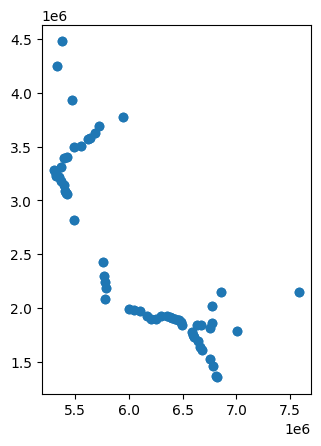

In [62]:
s1.plot()

In [63]:
# spatial join can tell you which stop falls into which CA or not
# if we do left join, then we keep all the points even if they
# do not intersect with CA
s2 = gpd.sjoin(
    amtrak_stops.to_crs("EPSG:2229"),
    ca2.to_crs("EPSG:2229"),
    how = "left",
    predicate = "intersects"
)

s2.shape

(1056, 8)

In [64]:
# Columns that do not intersect with CA are not populated for 
# `state` and `DISTRICT` and hold missing values
# but columns that do intersect with CA hold non-missing values
s2.tail() 

,agency,stop_id,stop_name,geometry,index_right,state,DISTRICT,Shape__Area
1051,Amtrak,YEM,Yemassee Amtrak,POINT (17740624.572 3434795.518),NaN,NaN,NaN,NaN
1052,Amtrak,YNY,Yonkers Amtrak Station,POINT (18428550.350 6997727.371),NaN,NaN,NaN,NaN
1053,Amtrak,YNY,Yonkers Amtrak Station,POINT (18428550.350 6997727.371),NaN,NaN,NaN,NaN
1054,Amtrak,YUM,Yuma Amtrak,POINT (7602942.501 1375180.799),NaN,NaN,NaN,NaN
1055,Amtrak,YUM,Yuma Amtrak,POINT (7602942.501 1375180.799),NaN,NaN,NaN,NaN


In [65]:
s2.loc[~s2.state.isna()].head()

,agency,stop_id,stop_name,geometry,index_right,state,DISTRICT,Shape__Area
30,Amtrak,ANA,Anaheim,POINT (6598941.918 1751004.184),0.0,CA,12.0,6.654531e+11
31,Amtrak,ANA,Anaheim,POINT (6598941.918 1751004.184),0.0,CA,12.0,6.654531e+11
38,Amtrak,ARN,Auburn Amtrak,POINT (5682083.082 3622327.697),0.0,CA,12.0,6.654531e+11
39,Amtrak,ARN,Auburn Amtrak,POINT (5682083.082 3622327.697),0.0,CA,12.0,6.654531e+11
54,Amtrak,BAR,Barstow,POINT (6853861.419 2153085.363),0.0,CA,12.0,6.654531e+11


<AxesSubplot:>

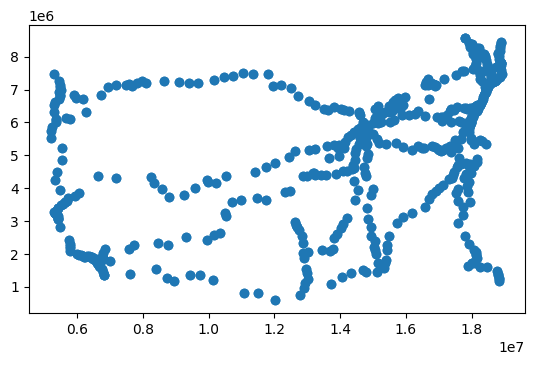

In [66]:
s2.plot()

In [67]:
# A right join is used if you want to keep only the inner join rows 
# (stops that intersect with CA)
# but use the geometry from the right

s3 = gpd.sjoin(
    amtrak_stops.to_crs("EPSG:2229"),
    ca2.to_crs("EPSG:2229"),
    how = "right",
    predicate = "intersects"
)

s3.shape

(124, 8)

<AxesSubplot:>

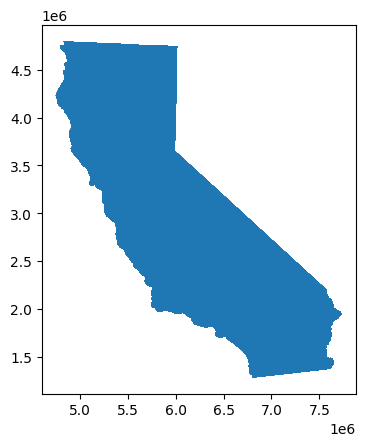

In [68]:
s3.plot()

## Overlay

**Recall**

Spatial joins do not change the **values** in the `geometry` column. The `how=` and `predicate=` arguments determine **which rows** are kept and **which geometry** column is kept. It does not change the contents of the geometry the way `gpd.overlay()` does.

Overlays **change the values** in the `geometry` column.

Polygons are the easiest to demonstrate these concepts, but typically, `overlay` can be used with lines or polygons.

#### how = intersection / symmetric difference / difference / identity
* `intersection` is the most common.
* `difference` might be of interest. 
* `symmetric_difference` is rare. This removes the middle intersection in the Venn Diagram.
* `identity` is rare.
* Look carefully at what columns are kept. If there are columns that aren't necessary, remove those columns.

,state,DISTRICT_1,Shape__Area_1,OBJECTID,DISTRICT_2,Region,Shape__Area_2,Shape__Length,geometry
0,CA,12,6.654531e+11,10,7,,2.358705e+10,714383.949603,"POLYGON ((6522138.902 1711989.744, 6514268.744..."


<AxesSubplot:>

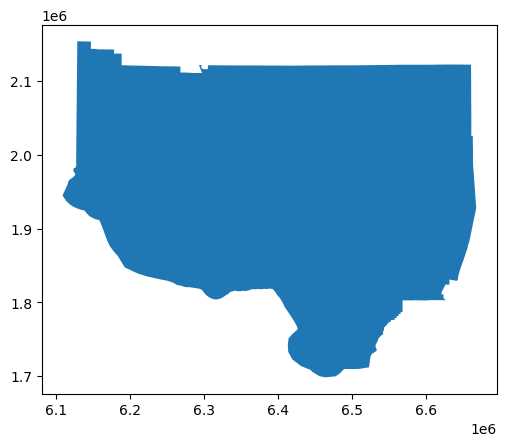

In [69]:
d7 = districts[districts.DISTRICT==7]

intersection_overlay = gpd.overlay(
    ca2,
    d7,
    how = "intersection", 
    keep_geom_type=True
)

display(intersection_overlay)
intersection_overlay.plot()

,state,DISTRICT_1,Shape__Area,DISTRICT_2,geometry
0,CA,12,6.654531e+11,7,"POLYGON ((6522138.902 1711989.744, 6514268.744..."


<AxesSubplot:>

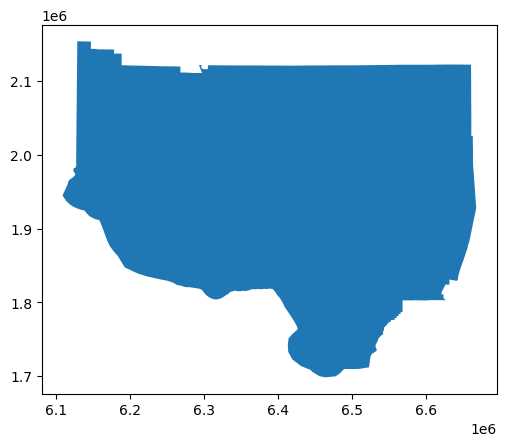

In [70]:
intersection_overlay2 = gpd.overlay(
    ca2,
    d7[["DISTRICT", "geometry"]],
    how = "intersection",
    keep_geom_type=True
)

display(intersection_overlay2)
intersection_overlay2.plot()

In [71]:
print(f"area before overlay: {ca.geometry.iloc[0].area}")
print(f"area after overlay: {intersection_overlay2.geometry.iloc[0].area}")

area before overlay: 4532640625587.922
area after overlay: 172532595239.97165


,state,geometry,DISTRICT,Shape__Area
0,CA,"POLYGON ((6102975.223 1948152.714, 6101936.635...",12,6.654531e+11


<AxesSubplot:>

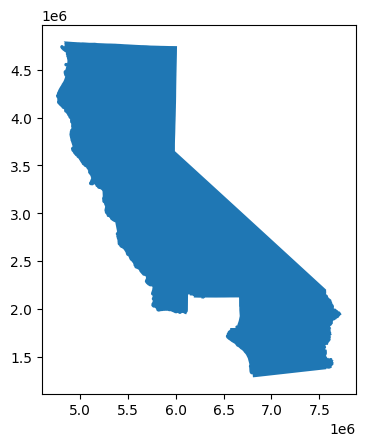

In [72]:
difference_overlay = gpd.overlay(
    ca2,
    d7[["DISTRICT", "geometry"]],
    how = "difference",
    keep_geom_type=True
)

display(difference_overlay)
difference_overlay.plot()

,DISTRICT,geometry
0,7,"MULTIPOLYGON (((6566115.510 1784372.072, 65661..."


<AxesSubplot:>

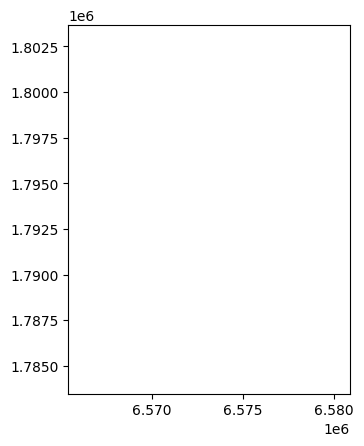

In [73]:
# From D7 polygon, remove the part that is CA..
# this is why it's plotting basically nothing
difference_overlay2 = gpd.overlay(
    d7[["DISTRICT", "geometry"]],
    ca2,
    how = "difference",
    keep_geom_type=True
)

display(difference_overlay2)
difference_overlay2.plot()